AGACA 0.01473716195685202
GGACT 0.1898831193715271
TGACT 0.028561228132809712
TCACT 0.01407364565259302
AGACC 0.011923276308968377
AGACT 0.07986564657585371
GGACA 0.057546468401486986
GGACG 0.03150442477876106
AGACG 0.018306636155606407
GGACC 0.042420256494574156


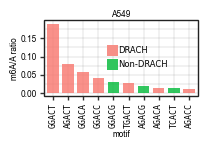

<ggplot: (192 x 133)>


In [1]:
import matplotlib.pyplot as plt
from plotnine import *
import pandas as pd
import numpy as np
import warnings
# Ignore all warnings
warnings.filterwarnings("ignore")
WT="/mnt/sunxh/sunxh/project/HEYA8/rep1.predict.tsv"

site_dict={}

with open(WT) as f:
    for line in f:
            line=line.rstrip()
            id="|".join(line.split("\t")[0:3])
            probability=float(line.split("\t")[5])
            if id not in site_dict:
                site_dict[id]=[0,0]
            if probability>0.9:
                site_dict[id][0]+=1
            site_dict[id][1]+=1

motif_dict={}
for id in site_dict:
    motif=id.split("|")[2]
    if motif not in motif_dict:
        motif_dict[motif]=[0,0]
    if site_dict[id][1]<5:
        continue
    if site_dict[id][0]/site_dict[id][1]>=0.5:
        motif_dict[motif][0]+=1
    motif_dict[motif][1] +=1  

    
diff_mod_dict={}
for motif in motif_dict:
    diff_mod_dict[motif]=motif_dict[motif][0]/motif_dict[motif][1]

black = '#222222'
gray = '#666666'
red = '#FF3333'
green = '#66CC00'
blue = '#3333FF'
purple = '#9933FF'
orange = '#FF8000'
yellow = '#FFFF33'
c1="#F8766D"
c2="#00BA38" 
c3="#619CFF"

import re
kmer_fillter="[AGT][AG]AC[ACT]"

motifs=[]
diff_mod_rates=[]
DRACH=[]

for motif in diff_mod_dict:
    if diff_mod_dict[motif]>0.0099:
        print(motif,diff_mod_dict[motif])
        motifs.append(motif)
        diff_mod_rates.append(diff_mod_dict[motif])
        if len([x.start() for x in re.finditer(kmer_fillter,motif)])==0:
            DRACH.append("Non-DRACH")
        else:
            DRACH.append("DRACH")
plt.rcParams["pdf.use14corefonts"] = True
data=pd.DataFrame({"motif":motifs,"m6A/A ratio":diff_mod_rates,"DRACH":DRACH})
data=data.sort_values(by=['m6A/A ratio'],ascending=False)        #sort
data['motif'] = pd.Categorical(data['motif'], categories=pd.unique(data['motif']))  #reorder legend
out_csv = "/mnt/sunxh/sunxh/wattmamba/new_result/fig6_motif_h9.csv"
data.to_csv(out_csv, index=False, encoding="utf-8-sig")

p=(
    ggplot()
    +geom_bar(data,aes(x="motif",y="m6A/A ratio",fill="DRACH",width=0.75),alpha=0.8,stat="identity")   
    
    #+scale_x_continuous(breaks = [0,100,200,300],labels =["               5'UTR", "                CDS", "                3'UTR",""])
    +theme(panel_background=element_rect(fill=gray, alpha=0),
            strip_text_x = element_text(size = 6),            #facet font size
            #legend_position = "none",
            panel_grid_major=element_line(size=0.3, alpha=0.3,color=black),
            panel_grid_minor=element_line(size=0.3, alpha=0.3,color=black),
            panel_border=element_rect(color=black, size=1),
            axis_text_x=element_text(size=6,family="Monospace",color="black",angle=90),
            axis_text_y=element_text(size=6,family="Arial",color="black"),
            axis_title_x=element_text(size=6,family="Arial",color="black"),
            axis_title_y=element_text(size=6,family="Arial",color="black"),
            plot_title=element_text(margin={'b': 1, 'r': 0, 'units': 'pt'},size=6,family="Arial",color="black"),
            figure_size=[1.92,1.33],
            legend_title = element_text(size=6,alpha=0), #change legend title font size
            legend_text = element_text(size=6),
            legend_background=element_rect(size=0.5,alpha=0),
            legend_position=(0.70,0.75), 
            legend_key_size=8) #change legend text font size)
    #+ geom_vline(xintercept=100,linetype="dashed",alpha=0.5)
    #+ geom_vline(xintercept=200,linetype="dashed",alpha=0.5)
    #+ylim([0,0.20])
    #+xlim([0,0.20])
    +scale_fill_manual(values=[c1, c2, c3]) 
    +labs(title='A549')
)
p.show()
print(p)
# p.save('figure/figure_5h_m6A_modified_motifs_A549.pdf')

In [2]:
import matplotlib.pyplot as plt
from plotnine import *
import pandas as pd
import numpy as np
import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")


WT="/mnt/sunxh/sunxh/project/HEYA8/rep1.predict.tsv"

site_dict={}

with open(WT) as f:
    for line in f:
            line=line.rstrip()
            id="|".join(line.split("\t")[0:3])
            probability=float(line.split("\t")[5])
            if id not in site_dict:
                site_dict[id]=[0,0]
            if probability>0.9:
                site_dict[id][0]+=1
            site_dict[id][1]+=1

motif_dict={}
for id in site_dict:
    motif=id.split("|")[2]
    if motif not in motif_dict:
        motif_dict[motif]=[0,0]
    if site_dict[id][1]<5:
        continue
    if site_dict[id][0]/site_dict[id][1]>=0.5:
        motif_dict[motif][0]+=1
    motif_dict[motif][1] +=1  

    
diff_mod_dict={}
for motif in motif_dict:
    diff_mod_dict[motif]=motif_dict[motif][0]/motif_dict[motif][1]

c1="#89C4FF"
c2="#CC99FF" 

import re
kmer_fillter="[AGT][AG]AC[ACT]"

motifs = []
diff_mod_rates = []
DRACH = []

for motif in diff_mod_dict:
    if diff_mod_dict[motif] > 0.005:
        motifs.append(motif)
        diff_mod_rates.append(diff_mod_dict[motif])
        if len([x.start() for x in re.finditer(kmer_fillter, motif)]) == 0:
            DRACH.append("Non-DRACH")
        else:
            DRACH.append("DRACH")

data = pd.DataFrame({
    "motif": motifs,
    "m6A/A ratio": diff_mod_rates,
    "DRACH": DRACH
})
data = data.sort_values(by=['m6A/A ratio'], ascending=False).head(10)
print(data)
data['motif'] = pd.Categorical(data['motif'], categories=pd.unique(data['motif']))  #reorder legend
data.to_csv('/mnt/sunxh/sunxh/wattmamba/result/fig7_HEYA8.csv', index=False, encoding='utf-8')

    motif  m6A/A ratio      DRACH
1   GGACT     0.189883      DRACH
13  AGACT     0.079866      DRACH
16  GGACA     0.057546      DRACH
21  GGACC     0.042420      DRACH
18  GGACG     0.031504  Non-DRACH
2   TGACT     0.028561      DRACH
20  AGACG     0.018307  Non-DRACH
0   AGACA     0.014737      DRACH
3   TCACT     0.014074  Non-DRACH
9   AGACC     0.011923      DRACH


In [7]:
WT="/mnt/sunxh/sunxh/project/HEYA8/rep1.predict.tsv"

import matplotlib.pyplot as plt
from collections import Counter

probalibility_cutoff = 0.9
min_depth = 5
site_rate_cutoff = 0.35
WT_count_dict = {}
with open(WT) as f:
    for line in f:
        line = line.rstrip("\n")
        if not line:
            continue
        cols = line.split("\t")
        if len(cols) < 6:
            continue
        site = f"{cols[0]}|{cols[1]}"
        try:
            mod_probability = float(cols[5])
        except ValueError:
            continue
        if site not in WT_count_dict:
            WT_count_dict[site] = [0, 0]
        if mod_probability > probalibility_cutoff:
            WT_count_dict[site][0] += 1
        WT_count_dict[site][1] += 1
gene_modified_site_count = Counter()  # gene -> N_modified_sites
for site, (mod_reads, total_reads) in WT_count_dict.items():
    if total_reads < min_depth:
        continue
    site_rate = mod_reads / total_reads
    if site_rate > site_rate_cutoff:
        gene = site.split("|")[0]
        gene_modified_site_count[gene] += 1


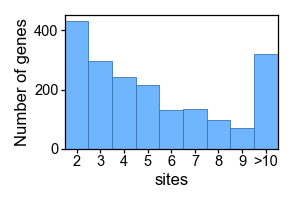

In [21]:
bins = [str(i) for i in range(2, 10)] + [">10"]
bin_counts = {b: 0 for b in bins}
for gene, n_sites in gene_modified_site_count.items():
    if n_sites < 2:
        continue
    if 2 <= n_sites <= 9:
        bin_counts[str(n_sites)] += 1
    else:
        bin_counts[">10"] += 1
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"
plt.rcParams["pdf.use14corefonts"] = False
plt.rcParams["font.size"] = 8
plt.rcParams["axes.linewidth"] = 0.6
x = list(bin_counts.keys())
y = [bin_counts[k] for k in x]

fig, ax = plt.subplots(figsize=(1.8, 1.2), dpi=150)
ax.bar(x, y, width=1.0, color="#6FB6FF", edgecolor="#3A74B7", linewidth=0.4)
ax.set_xlabel("sites", labelpad=2, fontname="Arial")
ax.set_ylabel("Number of genes", labelpad=2, fontname="Arial",fontsize=8)

ax.tick_params(axis="both", which="major", labelsize=7, pad=1, length=2, width=0.6)
for t in ax.get_xticklabels() + ax.get_yticklabels():
    t.set_fontname("Arial")
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)
ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_visible(True)

for side in ["top", "right", "left", "bottom"]:
    ax.spines[side].set_color("black")
    ax.spines[side].set_linewidth(0.6)
ax.margins(x=0)
fig.tight_layout(pad=0.2)
out_pdf = "/mnt/sunxh/sunxh/wattmamba/new_result/supfig17_hey8_sites_hist.pdf"
fig.savefig(out_pdf, format="pdf", dpi=1200, bbox_inches="tight", pad_inches=0.02)
plt.show()


In [6]:
import pandas as pd

site_rows = []
for site, (mod_reads, total_reads) in WT_count_dict.items():
    if total_reads < min_depth:
        continue
    site_rate = mod_reads / total_reads
    if site_rate > site_rate_cutoff:
        gene, pos = site.split("|", 1)
        site_rows.append({
            "gene": gene,
            "pos": pos,
            "site": site,
            "mod_reads": mod_reads,
            "total_reads": total_reads,
            "site_rate": site_rate
        })

df_site = pd.DataFrame(site_rows).sort_values(["gene", "pos"])
df_site.to_csv("/mnt/sunxh/sunxh/wattmamba/new_result/supfig17_hey8_sites.csv", index=False, encoding="utf-8-sig")

df_gene = (pd.DataFrame(list(gene_modified_site_count.items()), columns=["gene", "modified_sites_count"])
             .sort_values("modified_sites_count", ascending=False))
df_gene.to_csv("/mnt/sunxh/sunxh/wattmamba/new_result/supfig17_hey8_gene_counts.csv", index=False, encoding="utf-8-sig")


In [ ]:
import matplotlib.pyplot as plt
from plotnine import *
import pandas as pd
import numpy as np
import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")


WT="/mnt/sunxh/sunxh/project/HEYA8/rep1.predict.tsv"

site_dict={}

with open(WT) as f:
    for line in f:
            line=line.rstrip()
            id="|".join(line.split("\t")[0:3])
            probability=float(line.split("\t")[5])
            if id not in site_dict:
                site_dict[id]=[0,0]
            if probability>0.9:
                site_dict[id][0]+=1
            site_dict[id][1]+=1

motif_dict={}
for id in site_dict:
    motif=id.split("|")[2]
    if motif not in motif_dict:
        motif_dict[motif]=[0,0]
    if site_dict[id][1]<5:
        continue
    if site_dict[id][0]/site_dict[id][1]>=0.5:
        motif_dict[motif][0]+=1
    motif_dict[motif][1] +=1  

    
diff_mod_dict={}
for motif in motif_dict:
    diff_mod_dict[motif]=motif_dict[motif][0]/motif_dict[motif][1]

c1="#89C4FF"
c2="#CC99FF" 

import re
kmer_fillter="[AGT][AG]AC[ACT]"

motifs = []
diff_mod_rates = []
DRACH = []

for motif in diff_mod_dict:
    if diff_mod_dict[motif] > 0.005:
        motifs.append(motif)
        diff_mod_rates.append(diff_mod_dict[motif])
        if len([x.start() for x in re.finditer(kmer_fillter, motif)]) == 0:
            DRACH.append("Non-DRACH")
        else:
            DRACH.append("DRACH")

data = pd.DataFrame({
    "motif": motifs,
    "m6A/A ratio": diff_mod_rates,
    "DRACH": DRACH
})
data = data.sort_values(by=['m6A/A ratio'], ascending=False).head(10)
print(data)
data['motif'] = pd.Categorical(data['motif'], categories=pd.unique(data['motif']))  #reorder legend
data.to_csv('/mnt/sunxh/sunxh/wattmamba/result/fig7_HEYA8.csv', index=False, encoding='utf-8')